# Indonesia geohash

In [6]:
import numpy as np
import pandas as pd

In [7]:
data=pd.read_csv('dataset/training.csv')


In [8]:
data

,geohash6,day,timestamp,demand
0,qp03wc,18,20:0,0.020072
1,qp03pn,10,14:30,0.024721
2,qp09sw,9,6:15,0.102821
3,qp0991,32,5:0,0.088755
4,qp090q,15,4:0,0.074468
...,...,...,...,...
4206316,qp03y1,39,13:0,0.012731
4206317,qp097e,23,18:45,0.083179
4206318,qp03m6,32,12:15,0.123260
4206319,qp02zv,42,5:15,0.120100


In [9]:
data=pd.DataFrame(data)

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data["timestamp"].dtype

<StringDtype(na_value=nan)>

In [12]:
data["timestamp"] = data["timestamp"].astype(str).str.replace(".", ":", regex=False)

In [13]:
data[["Hour", "Minute",]] = data["timestamp"].astype(str).str.split(':', expand=True)


In [14]:
data["Hour"]=data["Hour"].astype(int)
data["Minute"]=data["Minute"].astype(int)


### preprocessing geohash column

In [15]:
!pip install pygeohash

In [16]:
data.rename(columns={"geohash6":"geohash"}, inplace=True)

In [17]:
import pygeohash as pgh

data["Latitude"]=data["geohash"].apply(lambda x: pgh.decode(x)[0])
data["Longitude"]=data["geohash"].apply(lambda x: pgh.decode(x)[1])

In [18]:
data['geohash_prefix'] = data['geohash'].str[:4]

In [19]:
data

,geohash,day,timestamp,demand,Hour,Minute,Latitude,Longitude,geohash_prefix
0,qp03wc,18,20:0,0.020072,20,0,-5.353088,90.653687,qp03
1,qp03pn,10,14:30,0.024721,14,30,-5.413513,90.664673,qp03
2,qp09sw,9,6:15,0.102821,6,15,-5.325623,90.906372,qp09
3,qp0991,32,5:0,0.088755,5,0,-5.353088,90.752563,qp09
4,qp090q,15,4:0,0.074468,4,0,-5.413513,90.719604,qp09
...,...,...,...,...,...,...,...,...,...
4206316,qp03y1,39,13:0,0.012731,13,0,-5.309143,90.620728,qp03
4206317,qp097e,23,18:45,0.083179,18,45,-5.386047,90.862427,qp09
4206318,qp03m6,32,12:15,0.123260,12,15,-5.391541,90.587769,qp03
4206319,qp02zv,42,5:15,0.120100,5,15,-5.462952,90.697632,qp02


In [20]:
data["time_slot"] = data["Hour"] * 4 + (data["Minute"] // 15)

In [21]:
data["rush_hour"] = (
    ((data["Hour"] >= 7) & (data["Hour"] <= 10)) |
    ((data["Hour"] >= 17) & (data["Hour"] <= 20))
).astype(int)


In [22]:
# Hour cyclic encoding
data["hour_sin"] = np.sin(2 * np.pi * data["Hour"] / 24)
data["hour_cos"] = np.cos(2 * np.pi * data["Hour"] / 24)

# Minute cyclic encoding
data["minute_sin"] = np.sin(2 * np.pi * data["Minute"] / 60)
data["minute_cos"] = np.cos(2 * np.pi * data["Minute"] / 60)





In [23]:
# Geohash prefixes

data["geo_4"] = data["geohash"].str[:4]
data["geo_5"] = data["geohash"].str[:5]
data["geo_6"] = data["geohash"].str[:6]

In [24]:
freq = data["geo_5"].value_counts()

data["geo_freq"] = data["geo_5"].map(freq)

In [25]:
data.columns

Index(['geohash', 'day', 'timestamp', 'demand', 'Hour', 'Minute', 'Latitude',
       'Longitude', 'geohash_prefix', 'time_slot', 'rush_hour', 'hour_sin',
       'hour_cos', 'minute_sin', 'minute_cos', 'geo_4', 'geo_5', 'geo_6',
       'geo_freq'],
      dtype='str')

In [26]:
data.isnull().sum()

geohash           0
day               0
timestamp         0
demand            0
Hour              0
Minute            0
Latitude          0
Longitude         0
geohash_prefix    0
time_slot         0
rush_hour         0
hour_sin          0
hour_cos          0
minute_sin        0
minute_cos        0
geo_4             0
geo_5             0
geo_6             0
geo_freq          0
dtype: int64

# Feature engineering

In [27]:
data

,geohash,day,timestamp,demand,Hour,Minute,Latitude,Longitude,geohash_prefix,time_slot,rush_hour,hour_sin,hour_cos,minute_sin,minute_cos,geo_4,geo_5,geo_6,geo_freq
0,qp03wc,18,20:0,0.020072,20,0,-5.353088,90.653687,qp03,80,1,-8.660254e-01,5.000000e-01,0.000000e+00,1.000000e+00,qp03,qp03w,qp03wc,174670
1,qp03pn,10,14:30,0.024721,14,30,-5.413513,90.664673,qp03,58,0,-5.000000e-01,-8.660254e-01,5.665539e-16,-1.000000e+00,qp03,qp03p,qp03pn,92454
2,qp09sw,9,6:15,0.102821,6,15,-5.325623,90.906372,qp09,25,0,1.000000e+00,6.123234e-17,1.000000e+00,2.832769e-16,qp09,qp09s,qp09sw,122560
3,qp0991,32,5:0,0.088755,5,0,-5.353088,90.752563,qp09,20,0,9.659258e-01,2.588190e-01,0.000000e+00,1.000000e+00,qp09,qp099,qp0991,129057
4,qp090q,15,4:0,0.074468,4,0,-5.413513,90.719604,qp09,16,0,8.660254e-01,5.000000e-01,0.000000e+00,1.000000e+00,qp09,qp090,qp090q,93581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4206316,qp03y1,39,13:0,0.012731,13,0,-5.309143,90.620728,qp03,52,0,-2.588190e-01,-9.659258e-01,0.000000e+00,1.000000e+00,qp03,qp03y,qp03y1,122083
4206317,qp097e,23,18:45,0.083179,18,45,-5.386047,90.862427,qp09,75,1,-1.000000e+00,-1.836970e-16,-1.000000e+00,-1.836970e-16,qp09,qp097,qp097e,111237
4206318,qp03m6,32,12:15,0.123260,12,15,-5.391541,90.587769,qp03,49,0,1.224647e-16,-1.000000e+00,1.000000e+00,2.832769e-16,qp03,qp03m,qp03m6,103882
4206319,qp02zv,42,5:15,0.120100,5,15,-5.462952,90.697632,qp02,21,0,9.659258e-01,2.588190e-01,1.000000e+00,2.832769e-16,qp02,qp02z,qp02zv,73678


In [28]:
from sklearn.model_selection import train_test_split
X=data.drop(['demand','timestamp','geohash_prefix','geohash'],axis=1)
y=data['demand']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [29]:
# geo_avg_demand
if "geo_avg_demand" not in X_train.columns:
    geo_mean = (
        X_train.join(y_train)
        .groupby("geo_5")["demand"]
        .mean()
        .reset_index()
        .rename(columns={"demand": "geo_avg_demand"})
    )
    X_data= X_train.merge(geo_mean, on="geo_5", how="left")
    X_test  = X_test.merge(geo_mean, on="geo_5", how="left")

# hour_avg_demand
if "hour_avg_demand" not in X_train.columns:
    hour_mean = (
        X_train.join(y_train)
        .groupby("Hour")["demand"]
        .mean()
        .reset_index()
        .rename(columns={"demand": "hour_avg_demand"})
    )

    X_train = X_train.merge(hour_mean, on="Hour", how="left")

    X_test  = X_test.merge(hour_mean, on="Hour", how="left")  

 
    

In [30]:
# Step 1: compute on train only (fix data leakage)
if "geo_time_demand_mean" not in X_train.columns:
    geo_time_mean = (
        X_train.join(y_train)
        .groupby(["geo_5", "time_slot"])["demand"]
        .mean()
        .reset_index()                                      # converts MultiIndex Series → DataFrame
        .rename(columns={"demand": "geo_time_demand_mean"}) # now the column exists
    )

    # Step 2: merge into X_train and X_test
    X_train = X_train.merge(geo_time_mean, on=["geo_5", "time_slot"], how="left")

    X_test  = X_test.merge(geo_time_mean, on=["geo_5", "time_slot"], how="left") 

    

In [31]:
## handling missing val in geo_time_demand_mean
global_mean = y_train.mean()

X_train["geo_time_demand_mean"] = (
    X_train["geo_time_demand_mean"]
    .fillna(global_mean)
)

X_test["geo_time_demand_mean"] = (
    X_test["geo_time_demand_mean"]
    .fillna(global_mean)
)



In [32]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [33]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [34]:
cat_features=['day','rush_hour','geo_4','geo_5','geo_6']
num_features=['geo_freq', 'Latitude', 'Longitude','Hour', 'Minute', 'time_slot','hour_sin','hour_cos','minute_sin','minute_cos','geo_time_demand_mean','hour_avg_demand']

numeric_transformer=StandardScaler()
cat_transformer=OneHotEncoder(handle_unknown='ignore')
preprocessor=ColumnTransformer(
    [
        ('scaler',numeric_transformer,num_features),
        ('onehotencoder',cat_transformer,cat_features)
        
    ]
)

In [35]:
y_train

1745522    0.029171
1049478    0.004343
2272225    0.017446
3868775    0.006429
3044193    0.028401
             ...   
4044887    0.250604
1136074    0.035527
1570006    0.029681
2234489    0.048348
1692743    0.567625
Name: demand, Length: 3365056, dtype: float64

In [36]:
print(X_train.shape)
print(X_test.shape)

(3365056, 17)
(841265, 18)


In [37]:
X_train.head(5)

,day,Hour,Minute,Latitude,Longitude,time_slot,rush_hour,hour_sin,hour_cos,minute_sin,minute_cos,geo_4,geo_5,geo_6,geo_freq,hour_avg_demand,geo_time_demand_mean
0,32,9,0,-5.248718,90.939331,36,1,0.707107,-0.707107,0.000000e+00,1.000000e+00,qp0d,qp0dj,qp0djk,58537,0.134312,0.103087
1,21,1,0,-5.364075,90.785522,4,0,0.258819,0.965926,0.000000e+00,1.000000e+00,qp09,qp093,qp093z,72905,0.097213,0.101826
2,40,13,30,-5.237732,90.829468,54,0,-0.258819,-0.965926,5.665539e-16,-1.000000e+00,qp0d,qp0d4,qp0d4y,58513,0.119139,0.122476
3,20,15,15,-5.281677,90.631714,61,0,-0.707107,-0.707107,1.000000e+00,2.832769e-16,qp03,qp03y,qp03yq,122083,0.088172,0.104473
4,23,15,15,-5.380554,90.620728,61,0,-0.707107,-0.707107,1.000000e+00,2.832769e-16,qp03,qp03q,qp03qh,155098,0.088172,0.107941


In [38]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [39]:
import pickle

with open("preprocessor.pkl", "wb") as f:
    pickle.dump({
        "num_features": num_features,
        "cat_features": cat_features,
        "preprocessor": preprocessor
    }, f)

In [38]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,mean_absolute_error,mean_squared_error,r2_score

## Hyper parameter tuning

In [49]:

lgb_model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.3,  
    reg_lambda=1,
    random_state=42
)
from catboost import CatBoostRegressor
cat_model = CatBoostRegressor(
    iterations=2000,        
    learning_rate=0.05,     
    depth=8,               
    l2_leaf_reg=3.0,    
    early_stopping_rounds=100,  
    random_seed=42,
    verbose=500,
    task_type="GPU",
    devices='0'
)
xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,   
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=1.0,  
    tree_method="hist", 
    device="cuda",
    random_state=42,
    eval_metric='rmse'
)

In [ ]:
lgb_model.fit(X_train, y_train)




In [42]:
import pickle
with open('lgb_model.pkl', "wb") as f:
    pickle.dump(lgb_model, f)

lgb_pred = lgb_model.predict(X_test)

c:\Users\saika\sruthi-genai\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [43]:
print(r2_score(y_test,lgb_pred))

0.9459898165661398


In [50]:
cat_model.fit(X_train,y_train)


with open('cat_model.pkl', "wb") as f:
    pickle.dump(cat_model, f)

cat_pred = cat_model.predict(X_test)

0:	learn: 0.1575147	total: 277ms	remaining: 9m 14s
500:	learn: 0.0749774	total: 36.5s	remaining: 1m 49s
1000:	learn: 0.0653711	total: 1m 13s	remaining: 1m 13s
1500:	learn: 0.0604711	total: 1m 54s	remaining: 38s
1999:	learn: 0.0572320	total: 2m 39s	remaining: 0us


In [51]:
print(r2_score(y_test,cat_pred))

0.8690929799206606


In [44]:
xgb_model.fit(X_train, y_train)

with open('xgb_model.pkl', "wb") as f:
    pickle.dump(xgb_model, f)

xgb_pred = xgb_model.predict(X_test)

In [48]:
print(r2_score(y_test,xgb_pred))

0.8782621240726125


In [ ]:
import pickle
with open('lgb_model.pkl', "wb") as f:
    pickle.dump(lgb_model, f)

lgb_pred = lgb_model.predict(X_test)

c:\Users\saika\sruthi-genai\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [54]:
# Predictions using optimized ensemble weights

from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error





p1 =lgb_pred  # LGB predictions
p2 = cat_pred  # CatBoost predictions
p3 = xgb_pred  # XGB predictions
  # RF predictions
import os
# Determine ensemble weights: prefer saved weights, then try to compute from previous validation preds, else fallback to sensible defaults
weights_path = 'ensemble_weights.npy'
w = None
if os.path.exists(weights_path):
    w = np.load(weights_path)
else:
    if all(var in globals() for var in ['cat_pred', 'lgb_pred', 'xgb_pred',  'y_test']):
        def loss_func(x):
            x = np.abs(x)
            x = x / x.sum()
            pred = x[0]*cat_pred + x[1]*lgb_pred + x[2]*xgb_pred 
            return mean_absolute_error(y_test, pred)

        res = minimize(loss_func, np.array([0.33,0.33,0.33]), method='Nelder-Mead')
        w = np.abs(res.x)
        w = w / w.sum()
        np.save(weights_path, w)
    else:
        w = np.array([0.0, 0.86, 0.14])

cat_w, lgb_w, xgb_w = w[0], w[1], w[2]
predictions = (cat_w * p2) + (lgb_w * p1) + (xgb_w * p3) 

print("Ensemble weights used:", w)


Ensemble weights used: [3.10331527e-06 9.99996616e-01 2.80671322e-07]


In [55]:
print(r2_score(y_test, predictions))

0.9459897435686553


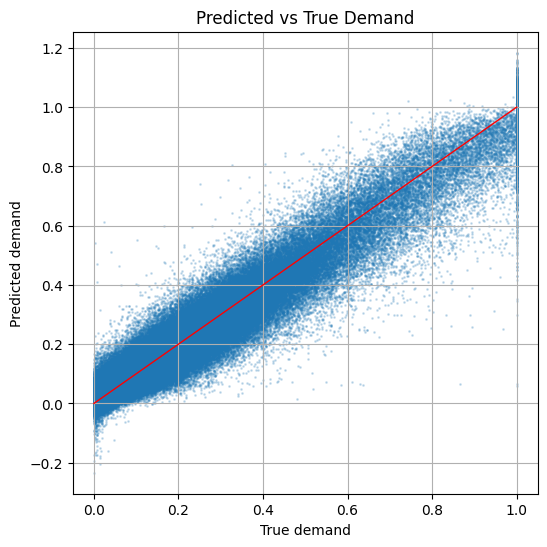

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.2, s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=1)
plt.xlabel("True demand")
plt.ylabel("Predicted demand")
plt.title("Predicted vs True Demand")
plt.grid(True)
plt.show()

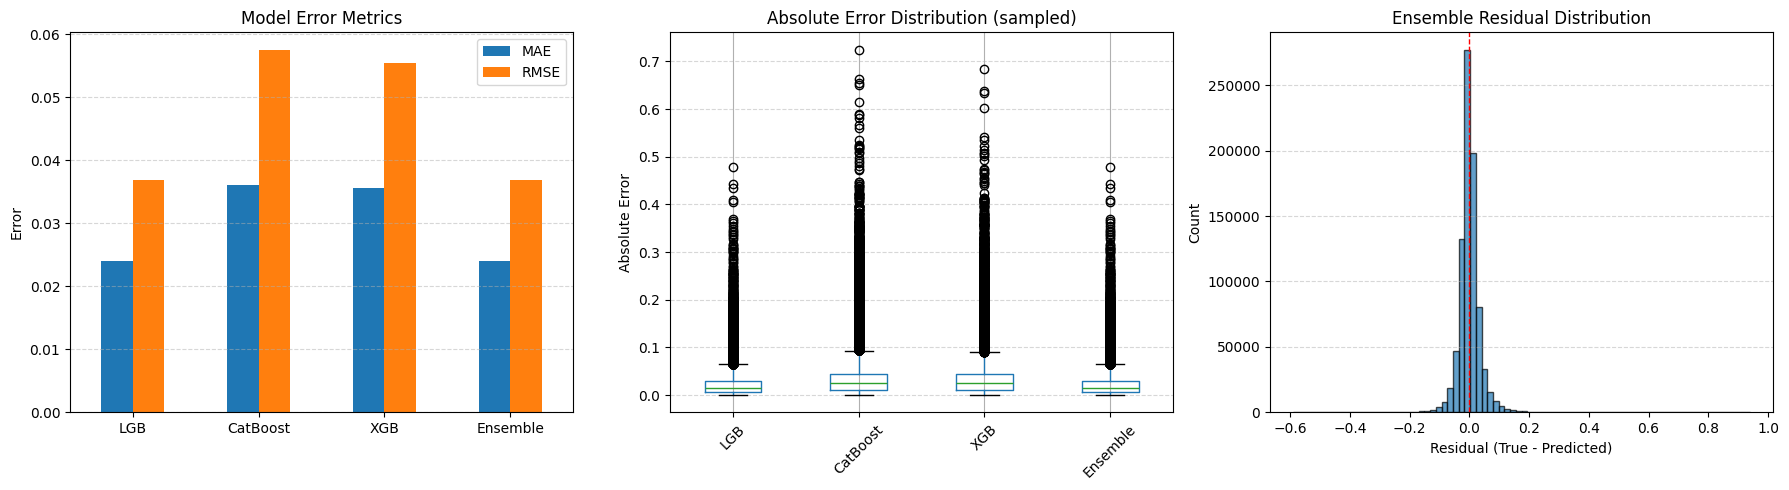

               MAE      RMSE        R2
LGB       0.023950  0.036869  0.945990
CatBoost  0.036110  0.057400  0.869093
XGB       0.035527  0.055353  0.878262
Ensemble  0.023950  0.036869  0.945990


In [63]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_preds = {
    "LGB": lgb_pred,
    "CatBoost": cat_pred,
    "XGB": xgb_pred,
    "Ensemble": predictions
}

metrics = {}
for name, preds in model_preds.items():
    metrics[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    }

metrics_df = pd.DataFrame(metrics).T

errors_df = pd.DataFrame(
    {
        name: np.abs(y_test.to_numpy() - preds)
        for name, preds in model_preds.items()
    }
)

residuals = y_test.to_numpy() - predictions

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
metrics_df[["MAE", "RMSE"]].plot(kind="bar", ax=plt.gca())
plt.title("Model Error Metrics")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.subplot(1, 3, 2)
errors_df.sample(n=50000, random_state=42).boxplot(rot=45, ax=plt.gca())
plt.title("Absolute Error Distribution (sampled)")
plt.ylabel("Absolute Error")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.subplot(1, 3, 3)
plt.hist(residuals, bins=80, alpha=0.7, color="tab:blue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title("Ensemble Residual Distribution")
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(metrics_df)

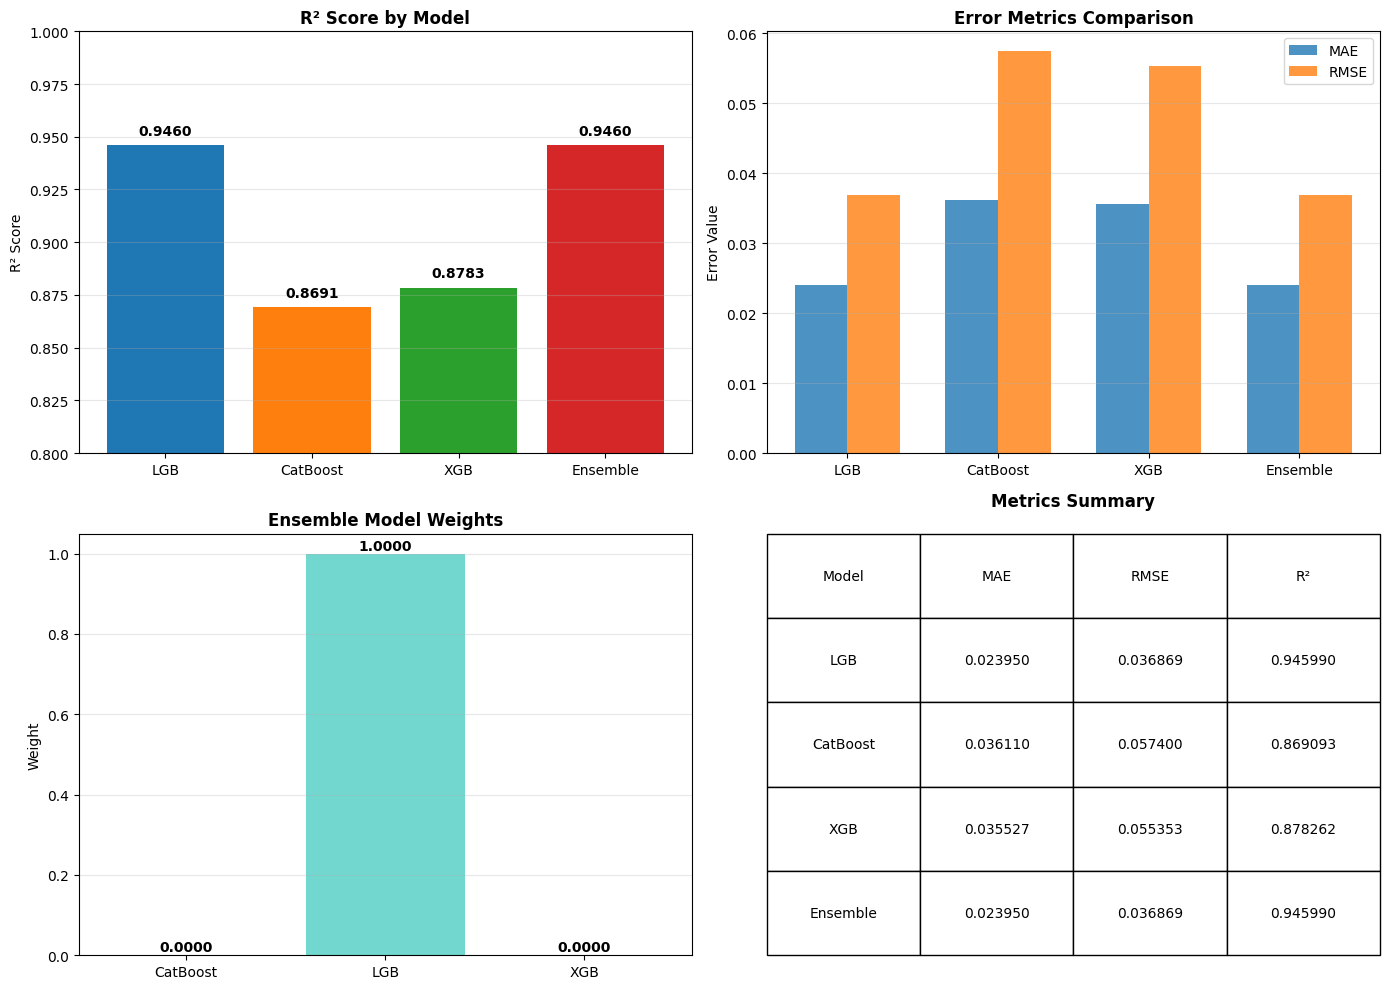

In [64]:
# Create comprehensive metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Model Comparison - R2 Score
axes[0, 0].bar(metrics_df.index, metrics_df['R2'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0, 0].set_title('R² Score by Model', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_ylim([0.8, 1.0])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(metrics_df['R2']):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 2: Model Comparison - MAE and RMSE
x = np.arange(len(metrics_df.index))
width = 0.35
axes[0, 1].bar(x - width/2, metrics_df['MAE'], width, label='MAE', alpha=0.8)
axes[0, 1].bar(x + width/2, metrics_df['RMSE'], width, label='RMSE', alpha=0.8)
axes[0, 1].set_title('Error Metrics Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Error Value')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(metrics_df.index)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Ensemble Weights
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[1, 0].bar(['CatBoost', 'LGB', 'XGB'], [cat_w, lgb_w, xgb_w], color=colors, alpha=0.8)
axes[1, 0].set_title('Ensemble Model Weights', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Weight')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate([cat_w, lgb_w, xgb_w]):
    axes[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 4: Metrics Summary Table
axes[1, 1].axis('off')
table_data = []
for model in metrics_df.index:
    table_data.append([
        model,
        f"{metrics_df.loc[model, 'MAE']:.6f}",
        f"{metrics_df.loc[model, 'RMSE']:.6f}",
        f"{metrics_df.loc[model, 'R2']:.6f}"
    ])
table = axes[1, 1].table(cellText=table_data, 
                         colLabels=['Model', 'MAE', 'RMSE', 'R²'],
                         cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1, 1].set_title('Metrics Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()